In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cleaning Data

In [36]:
data_path   = os.path.join(os.getcwd(), "data")
fut_path    = os.path.join(data_path, "RawFuturesPX.parquet")
spot_path   = os.path.join(data_path, "EquityIndexSpotPrices.xlsx")
ticker_path = os.path.join(data_path, "TickerGuide.xlsx") 

In [34]:
df_spot_px = (pd.read_excel(
    io = spot_path).
    rename(columns = {"Date": "date"}).
    melt(id_vars = "date", var_name = "ticker", value_name = "spot_px"))

In [60]:
df_fut_px = (pd.read_parquet(
    path = fut_path, engine = "pyarrow"))

In [68]:
tickers = {"SMI": "SM1 Index"}
for ticker in tickers.keys():

    df_spot_tmp = (df_spot_px.query(
        "ticker == @ticker").
        set_index("date"))

    fut_ticker = tickers[ticker]
    df_fut_tmp = df_fut_px.query("ticker == @fut_ticker")
    break

<Axes: xlabel='date'>

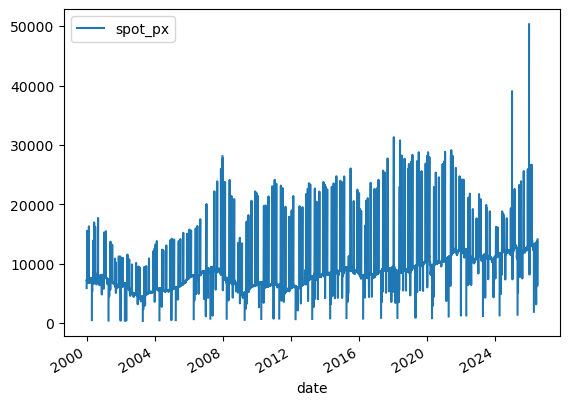

In [76]:
(df_spot_tmp[["spot_px"]].plot())